1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

2. Load the Diabetes Dataset

In [2]:
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target
print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("Feature names:", diabetes.feature_names)

Feature shape: (442, 10)
Target shape: (442,)
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


3. Create a DataFrame

In [3]:
df = pd.DataFrame(X, columns=diabetes.feature_names)
df['target'] = y
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


Check the dataset:

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


Check missing values:

In [5]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


Check duplicates:

In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


Since the sklearn Diabetes dataset normally contains no missing values, no imputation is required.

4. Statistical Summary

In [7]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


5. Exploratory Data Analysis

5.1 Distribution of Target Variable



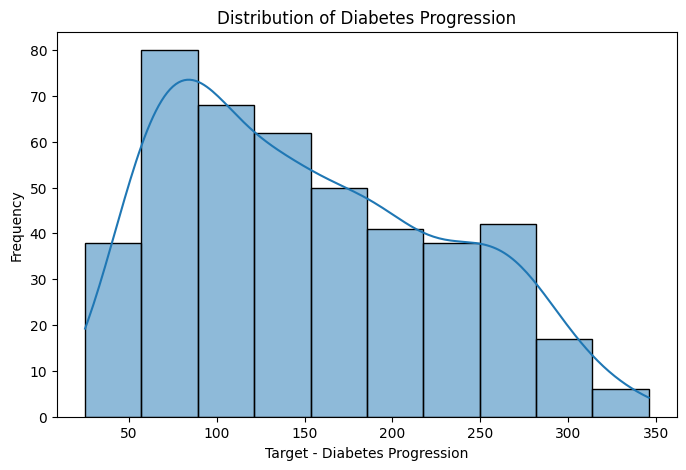

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df['target'], kde=True)
plt.title('Distribution of Diabetes Progression')
plt.xlabel('Target - Diabetes Progression')
plt.ylabel('Frequency')
plt.show()

5.2 Distribution of Features

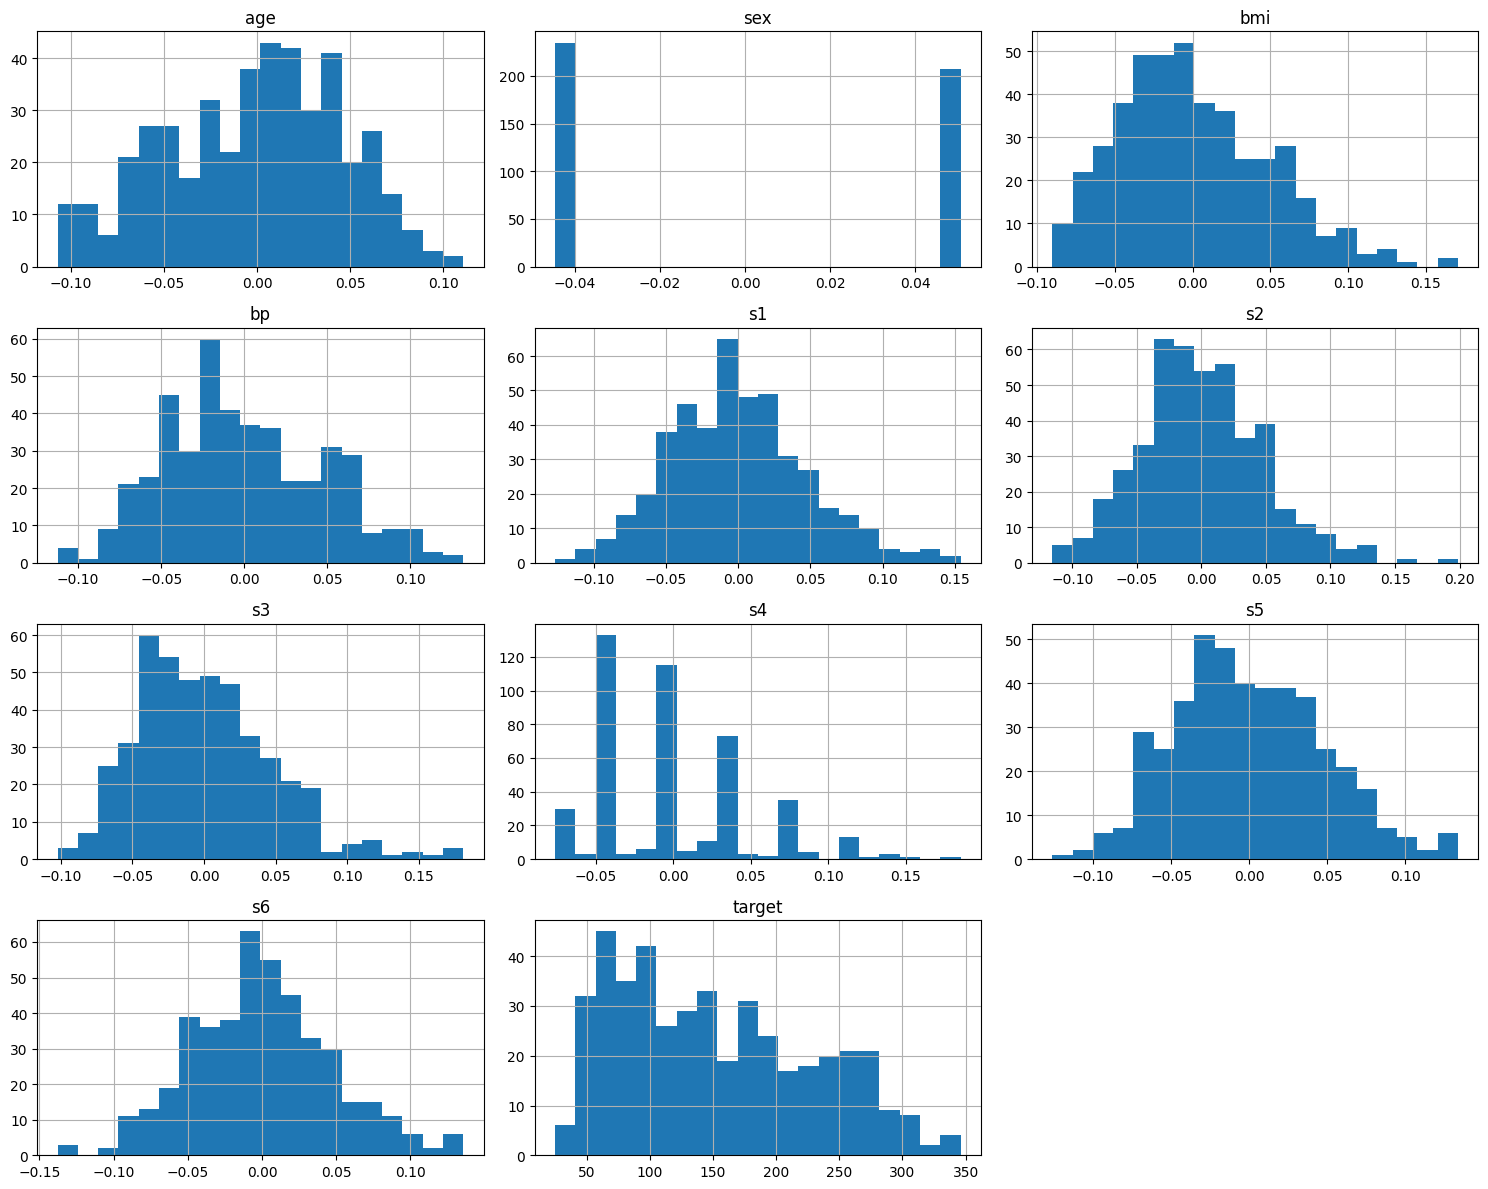

In [9]:
df.hist(figsize=(15, 12), bins=20)
plt.tight_layout()
plt.show()

6. Correlation Heatmap

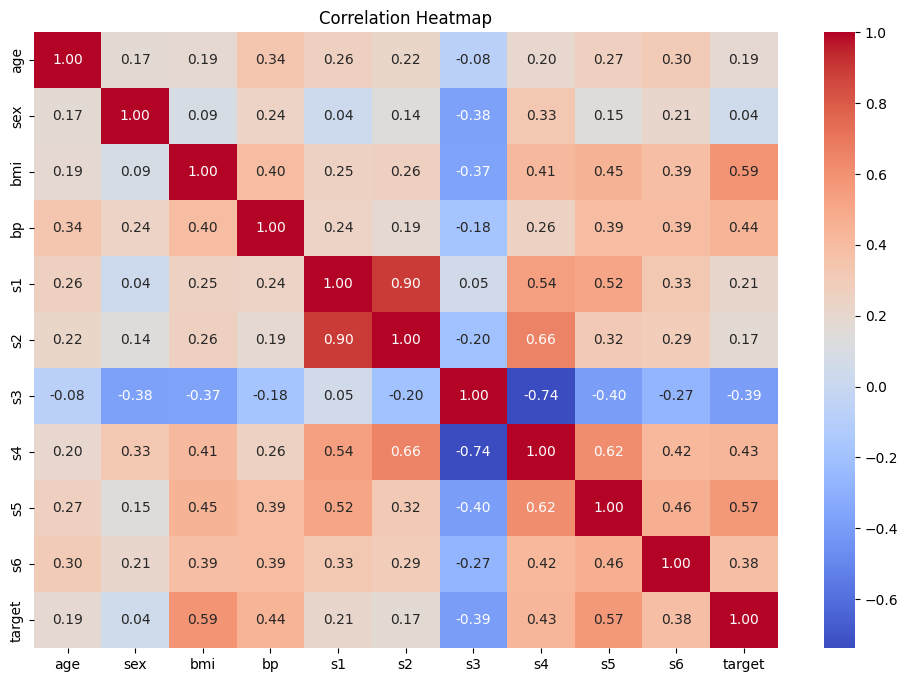

In [10]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f' )
plt.title('Correlation Heatmap')
plt.show()

This helps identify relationships between the independent variables and diabetes progression.

7. Feature vs Target Relationships

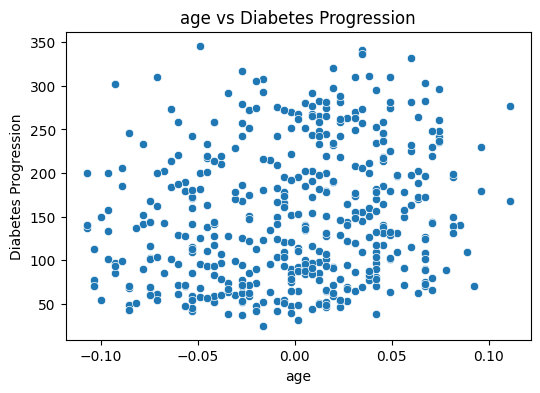

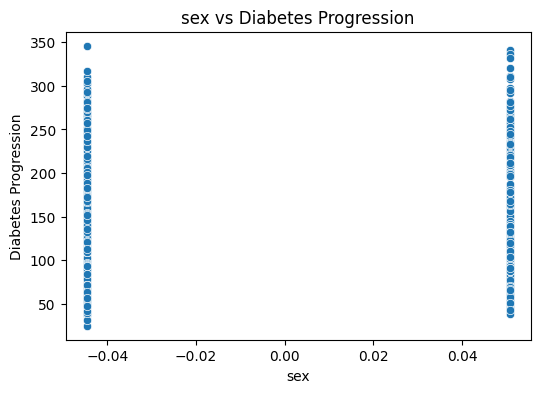

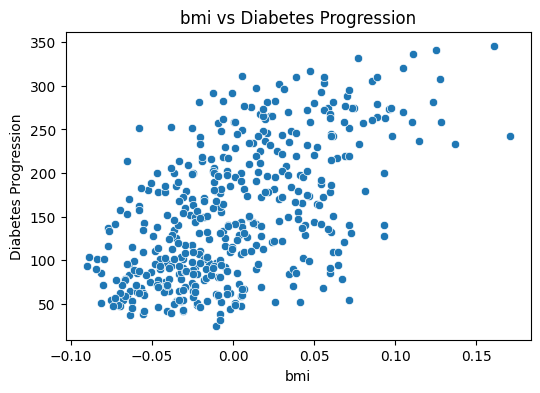

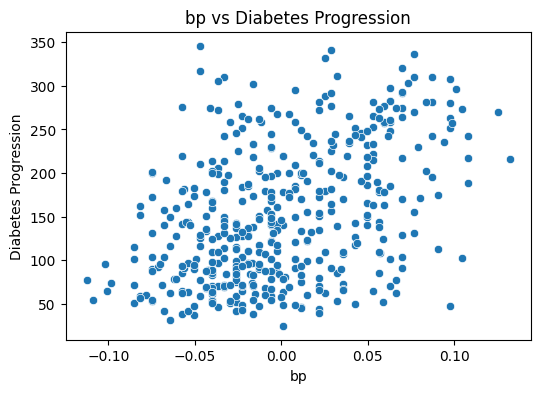

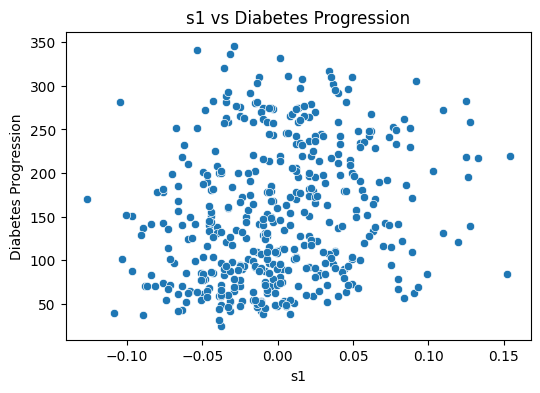

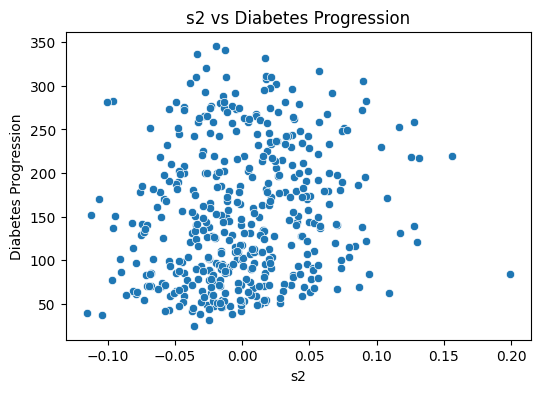

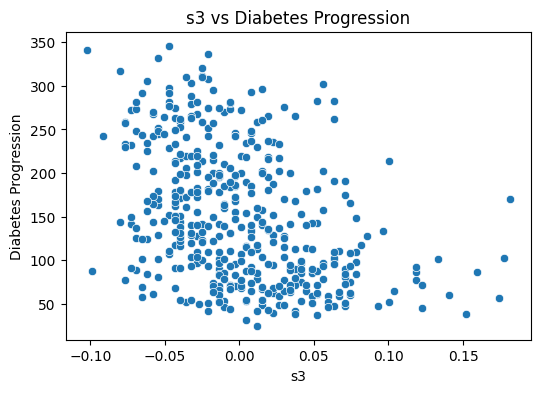

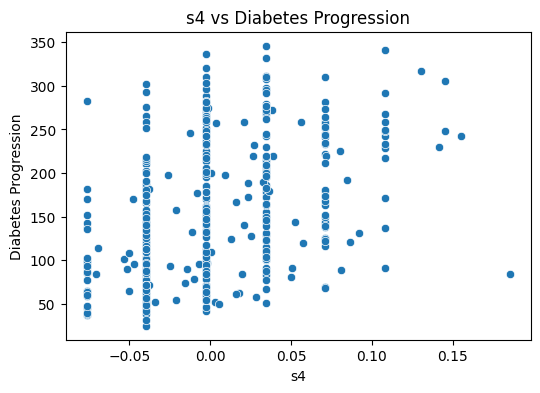

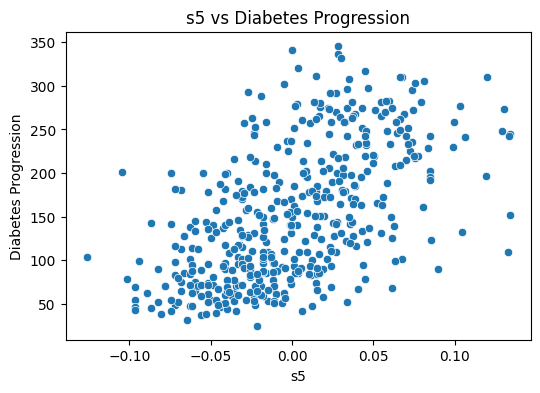

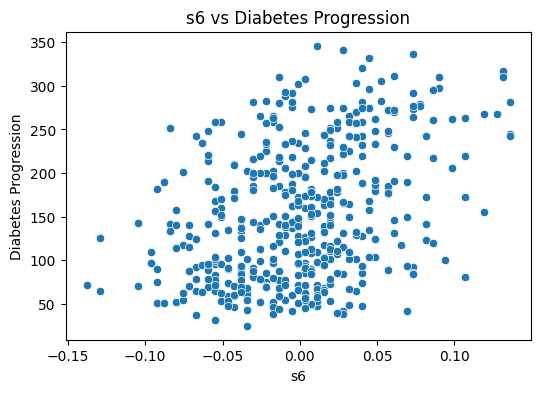

In [11]:
features = diabetes.feature_names
for feature in features:
  plt.figure(figsize=(6, 4))

  sns.scatterplot(
      x=df[feature],
      y=df['target']
       )

  plt.title(f'{feature} vs Diabetes Progression')
  plt.xlabel(feature)
  plt.ylabel('Diabetes Progression')
  plt.show()

8. Prepare Data for ANN

In [12]:
X = df[diabetes.feature_names]
y = df['target']

Split the data into training and testing sets.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(    X,    y,    test_size=0.20,    random_state=42 )
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (353, 10)
Testing data: (89, 10)


9. Normalize the Features

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

10. Build the Basic ANN Model

In [15]:
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(1, activation='linear')
    ])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 385 (1.50 KB)

 Trainable params: 385 (1.50 KB)

 Non-trainable params: 0 (0.00 B)

11. Compile the ANN

In [16]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae'] )

12. Train the ANN

In [17]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.20,
    epochs=100,
    batch_size=16,
    verbose=1 )

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 31459.8750 - mae: 158.5863 - val_loss: 22405.3066 - val_mae: 133.8843
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 31339.6953 - mae: 158.2378 - val_loss: 22320.5430 - val_mae: 133.5808
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 31219.0918 - mae: 157.8877 - val_loss: 22233.2051 - val_mae: 133.2764
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 31088.4219 - mae: 157.5123 - val_loss: 22140.8125 - val_mae: 132.9527
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 30949.9961 - mae: 157.1201 - val_loss: 22042.8691 - val_mae: 132.6129
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 30797.0176 - mae: 156.6929 - val_loss: 21935.9863 - val_mae: 132.2441
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 30633.0488 - mae: 156.2300 - val_loss: 21818.9609 - val_mae: 131.8472
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 30447.2949 - mae: 155.7133 - val_los

13. Plot Training and Validation Loss

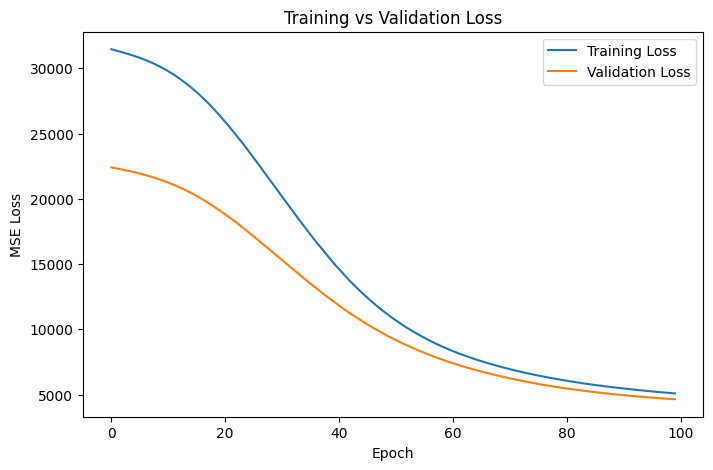

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

14. Evaluate the Basic ANN

In [19]:
y_pred = model.predict(X_test_scaled).flatten()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


Calculate MSE:

In [20]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 5152.81757782813


Calculate RMSE:

In [21]:
rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 71.78312878266125


Calculate R²:

In [22]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.02743110759882672


15. Actual vs Predicted Values

In [23]:
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred })
results.head(10)

,Actual,Predicted
0,219.0,129.928833
1,70.0,145.597809
2,202.0,101.332214
3,230.0,405.035492
4,111.0,62.295792
5,84.0,29.030289
6,242.0,249.488342
7,272.0,191.904083
8,94.0,46.189583
9,96.0,16.402218


16. Actual vs Predicted Plot

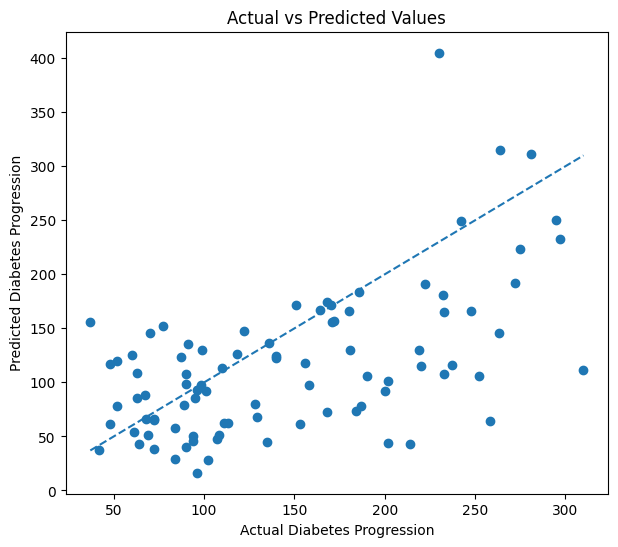

In [24]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Diabetes Progression')
plt.ylabel('Predicted Diabetes Progression')
plt.title('Actual vs Predicted Values')

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--' )
plt.show()

17. Improve the ANN Model

Instead of simply increasing the number of neurons, we can experiment with:
1. More hidden layers
2. Different number of neurons
3. Dropout
4. Lower learning rate
5. Early stopping

In [25]:
improved_model = Sequential([
     Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
     Dense(32, activation='relu'),
     Dense(16, activation='relu'),
     Dense(1, activation='linear')
])

improved_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

18. Compile Improved Model

In [26]:
improved_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

19. Add Early Stopping

In [27]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
    )

20. Train Improved Model

In [28]:
history_improved = improved_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.20,
    epochs=300,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
    )

Epoch 1/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 31444.1836 - mae: 158.4106 - val_loss: 22367.4844 - val_mae: 133.6711
Epoch 2/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 31267.7773 - mae: 157.8925 - val_loss: 22229.5684 - val_mae: 133.1805
Epoch 3/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 31048.9141 - mae: 157.2389 - val_loss: 22041.6348 - val_mae: 132.5152
Epoch 4/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 30737.2383 - mae: 156.3326 - val_loss: 21775.6895 - val_mae: 131.5681
Epoch 5/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 30281.7695 - mae: 154.9877 - val_loss: 21380.7539 - val_mae: 130.1562
Epoch 6/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 29598.2227 - mae: 152.9393 - val_loss: 20771.3984 - val_mae: 127.9611
Epoch 7/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 28552.5449 - mae: 149.7789 - val_loss: 19891.0449 - val_mae: 124.7333
Epoch 8/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 27017.8633 - mae: 145.1344 - va

21. Evaluate Improved Model

In [29]:
improved_pred = improved_model.predict(X_test_scaled).flatten()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


In [30]:
improved_mse = mean_squared_error(
    y_test,
    improved_pred
)

print("Improved MSE:", improved_mse)

Improved MSE: 2994.989834627341


In [31]:
improved_rmse = np.sqrt(improved_mse)
print("Improved RMSE:", improved_rmse)

Improved RMSE: 54.726500295810446


In [32]:
improved_r2 = r2_score(
    y_test,
    improved_pred )
print("Improved R2 Score:", improved_r2)

Improved R2 Score: 0.43471044681461024


22. Compare Basic and Improved Models

In [33]:
comparison = pd.DataFrame({
    'Model': [
        'Basic ANN',
        'Improved ANN'
        ],
    'MSE': [
        mse,
        improved_mse
        ],
     'RMSE': [
         rmse,
         improved_rmse
         ],
    'R2 Score': [
              r2,
              improved_r2
              ]
    })

comparison

,Model,MSE,RMSE,R2 Score
0,Basic ANN,5152.817578,71.783129,0.027431
1,Improved ANN,2994.989835,54.726500,0.434710


23. Plot Improved Training

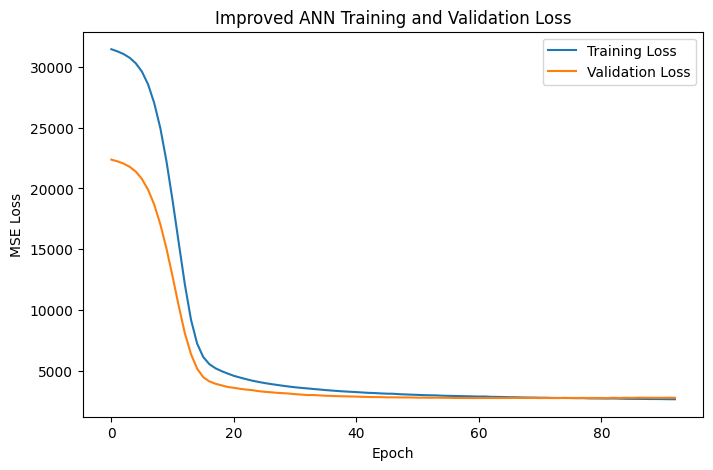

In [34]:
plt.figure(figsize=(8, 5))
plt.plot(
    history_improved.history['loss'],
    label='Training Loss'
    )
plt.plot(
    history_improved.history['val_loss'],
    label='Validation Loss'
    )
plt.title('Improved ANN Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

24. Final Actual vs Predicted Plot

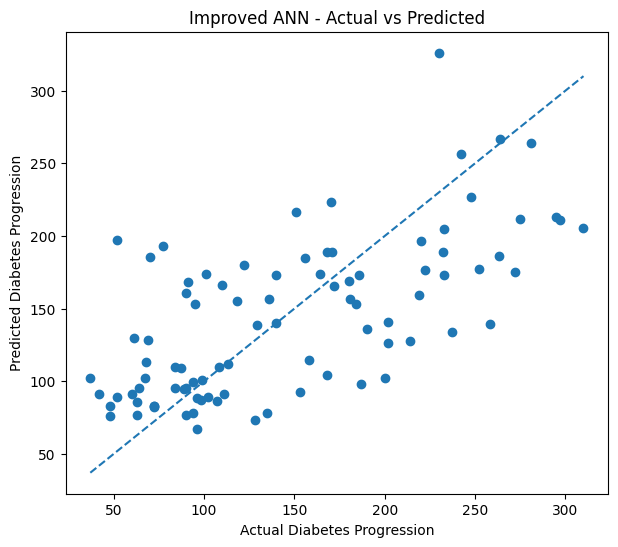

In [35]:
plt.figure(figsize=(7, 6))
plt.scatter(    y_test,    improved_pred )
plt.xlabel('Actual Diabetes Progression')
plt.ylabel('Predicted Diabetes Progression')
plt.title('Improved ANN - Actual vs Predicted')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--' )
plt.show()

Conclusion:
1. An Artificial Neural Network (ANN) regression model was developed to predict diabetes disease progression using the Diabetes dataset from the scikit-learn library.
2. The dataset contained 10 independent variables and a continuous target variable.
3. The data was checked for missing values and the features were standardized using StandardScaler.
4. Exploratory Data Analysis was performed using statistical summaries, distributions, correlation analysis, and scatter plots to understand the relationships between the independent variables and diabetes progression.
5. A basic ANN containing one hidden layer was initially developed using ReLU activation and a linear output layer.
The model was trained using the Adam optimizer and Mean Squared Error loss function.
6. Its performance was evaluated using MSE, RMSE, and R² score.
The model was subsequently improved by increasing the network depth and number of neurons, reducing the learning rate, and introducing early stopping.
7. The performance of the basic and improved models was compared using the same test dataset.
8. The ANN demonstrates that neural networks can be applied to regression problems involving multiple patient-related variables. However, the model should be considered a machine-learning exercise rather than a clinical treatment or diagnostic tool, since the sklearn dataset is a small benchmark dataset rather than a clinical dataset suitable for treatment decisions.